# Importing libraries and dataset

In [1]:
import networkx as nx
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
edges_df = pd.read_csv('/content/drive/MyDrive/CSE-Data-Mining-Warehouse-Lab-426/Week 06-Search Engine Design/web_graph.csv')
content_df = pd.read_csv('/content/drive/MyDrive/CSE-Data-Mining-Warehouse-Lab-426/Week 06-Search Engine Design/web_content.csv')

In [4]:
edges_df

,Source,Target
0,CodeAcademy.com,MLHub.com
1,DataScience101.com,DeepLearningCentral.com
2,MachineLearningMastery.com,AIWorld.com
3,PyProgramming.com,DataMiningExperts.com
4,DeepLearningCentral.com,DataMiningExperts.com
5,NeuralNetworksToday.com,BigDataSolutions.com
6,BigDataSolutions.com,MachineLearningMastery.com
7,AIWorld.com,CodeAcademy.com
8,MLHub.com,NeuralNetworksToday.com
9,DataScience101.com,AIWorld.com


In [5]:
content_df

,Website,Content
0,CodeAcademy.com,Learn programming from scratch. Courses availa...
1,MLHub.com,The best platform for machine learning enthusi...
2,DataScience101.com,Introduction to data science concepts. Coverin...
3,PyProgramming.com,Master Python programming through tutorials an...
4,DeepLearningCentral.com,Deep learning tutorials with TensorFlow and Py...
5,DataMiningExperts.com,Explore data mining techniques such as classif...
6,AIWorld.com,Everything about artificial intelligence: neur...
7,MachineLearningMastery.com,Your guide to mastering machine learning with ...
8,BigDataSolutions.com,"Learn big data tools and techniques: Hadoop, S..."
9,NeuralNetworksToday.com,Get updated on the latest advancements in neur...


# 02 Creating graph from web connections

In [6]:
web_graph = nx.DiGraph()
for _, row in edges_df.iterrows():
    web_graph.add_edge(row["Source"], row["Target"])

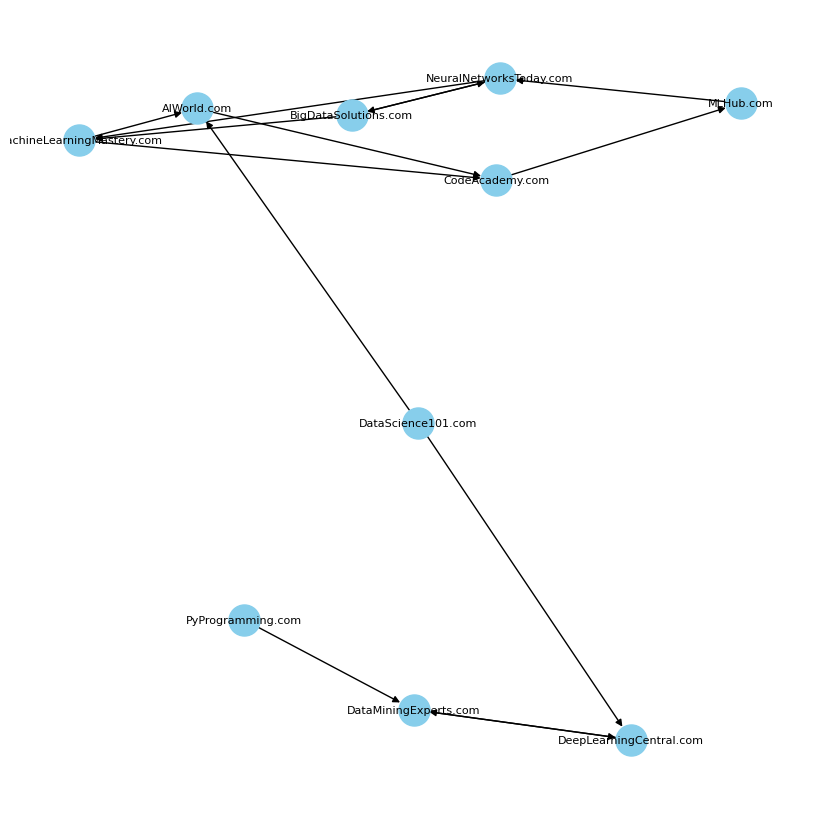

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
nx.draw(web_graph, with_labels=True, node_size=500, node_color="skyblue", font_size=8, font_color="black", arrowsize=10)
plt.show()

# Loading web content

In [8]:
# Load the content file into a dictionary
web_content = dict(zip(content_df["Website"], content_df["Content"]))

In [9]:
print("Nodes:", web_graph.nodes())
print("Edges:", web_graph.edges())
print("\nWebsite Content:")
for site, content in web_content.items():
    print(f"{site}: {content}")

Nodes: ['CodeAcademy.com', 'MLHub.com', 'DataScience101.com', 'DeepLearningCentral.com', 'MachineLearningMastery.com', 'AIWorld.com', 'PyProgramming.com', 'DataMiningExperts.com', 'NeuralNetworksToday.com', 'BigDataSolutions.com']
Edges: [('CodeAcademy.com', 'MLHub.com'), ('MLHub.com', 'NeuralNetworksToday.com'), ('DataScience101.com', 'DeepLearningCentral.com'), ('DataScience101.com', 'AIWorld.com'), ('DeepLearningCentral.com', 'DataMiningExperts.com'), ('MachineLearningMastery.com', 'AIWorld.com'), ('MachineLearningMastery.com', 'CodeAcademy.com'), ('AIWorld.com', 'CodeAcademy.com'), ('PyProgramming.com', 'DataMiningExperts.com'), ('DataMiningExperts.com', 'DeepLearningCentral.com'), ('NeuralNetworksToday.com', 'BigDataSolutions.com'), ('NeuralNetworksToday.com', 'MachineLearningMastery.com'), ('BigDataSolutions.com', 'MachineLearningMastery.com'), ('BigDataSolutions.com', 'NeuralNetworksToday.com')]

Website Content:
CodeAcademy.com: Learn programming from scratch. Courses available

# Calculating HITS score

In [10]:
hubs, authorities = nx.hits(web_graph, max_iter=100, tol=1e-6)
print("\nHITS - Hub Scores:", hubs)
print("\nHITS - Authority Scores:", authorities)


HITS - Hub Scores: {'CodeAcademy.com': -0.0, 'MLHub.com': 1.6258839764163448e-17, 'DataScience101.com': 0.3535533905932737, 'DeepLearningCentral.com': -4.8776519292490344e-17, 'MachineLearningMastery.com': 0.3535533905932738, 'AIWorld.com': 0.14644660940672632, 'PyProgramming.com': -4.8776519292490344e-17, 'DataMiningExperts.com': 0.14644660940672619, 'NeuralNetworksToday.com': 1.1381187834914413e-16, 'BigDataSolutions.com': 9.755303858498069e-17}

HITS - Authority Scores: {'CodeAcademy.com': 0.29289321881345265, 'MLHub.com': -0.0, 'DataScience101.com': -0.0, 'DeepLearningCentral.com': 0.29289321881345237, 'MachineLearningMastery.com': 1.6258839764163447e-16, 'AIWorld.com': 0.4142135623730949, 'PyProgramming.com': -0.0, 'DataMiningExperts.com': -9.755303858498069e-17, 'NeuralNetworksToday.com': 3.2517679528326896e-17, 'BigDataSolutions.com': 6.503535905665379e-17}


# Calculating PageRank Scores

In [11]:
pagerank_scores = nx.pagerank(web_graph, alpha=0.85, max_iter=100, tol=1e-6)
print("\nPageRank Scores:", pagerank_scores)


PageRank Scores: {'CodeAcademy.com': 0.1203296561037154, 'MLHub.com': 0.11728020765387914, 'DataScience101.com': 0.015000000000000003, 'DeepLearningCentral.com': 0.16202484883598653, 'MachineLearningMastery.com': 0.11085647826428258, 'AIWorld.com': 0.06848900329502798, 'PyProgramming.com': 0.015000000000000003, 'DataMiningExperts.com': 0.1654751511640137, 'NeuralNetworksToday.com': 0.14775063486506868, 'BigDataSolutions.com': 0.07779401981802624}


# Inverted Index Building

In [12]:
def inverted_index(web_content):
    inverted_index = {}
    for website, content in web_content.items():
        words = content.lower().split()
        for word in words:
            if word not in inverted_index:
                inverted_index[word] = []
            inverted_index[word].append(website)
    return inverted_index

In [13]:
index = inverted_index(web_content)
print("\nInverted Index:")
for word, websites in index.items():
    print(f"{word}: {websites}")


Inverted Index:
learn: ['CodeAcademy.com', 'PyProgramming.com', 'DeepLearningCentral.com', 'BigDataSolutions.com']
programming: ['CodeAcademy.com', 'PyProgramming.com']
from: ['CodeAcademy.com']
scratch.: ['CodeAcademy.com']
courses: ['CodeAcademy.com']
available: ['CodeAcademy.com']
in: ['CodeAcademy.com', 'NeuralNetworksToday.com']
python,: ['CodeAcademy.com']
javascript,: ['CodeAcademy.com']
c++.: ['CodeAcademy.com']
the: ['MLHub.com', 'NeuralNetworksToday.com']
best: ['MLHub.com']
platform: ['MLHub.com']
for: ['MLHub.com']
machine: ['MLHub.com', 'MachineLearningMastery.com']
learning: ['MLHub.com', 'DeepLearningCentral.com', 'MachineLearningMastery.com', 'NeuralNetworksToday.com']
enthusiasts.: ['MLHub.com']
tutorials,: ['MLHub.com']
models,: ['MLHub.com']
and: ['MLHub.com', 'DataScience101.com', 'PyProgramming.com', 'PyProgramming.com', 'DeepLearningCentral.com', 'DeepLearningCentral.com', 'DataMiningExperts.com', 'AIWorld.com', 'BigDataSolutions.com', 'BigDataSolutions.com', 'Ne

# Search Function

In [14]:
def search_engine(query, index, scores):
    query_terms = query.lower().split()
    results = set()
    for term in query_terms:
        if term in index:
            if not results:
                results = set(index[term])
            else:
                results = results.intersection(index[term])  # Find common websites

    # Sort results based on score
    ranked_results = []
    for website in results:
        if website in scores:
          ranked_results.append((website, scores[website]))
    ranked_results.sort(key=lambda x: x[1], reverse=True)

    return ranked_results

# Query

In [15]:
# Query and display results
query = "neural network"
print(f"\nSearch Results for '{query}' using PageRank:")
results = search_engine(query, index, pagerank_scores)

for page, score in results:
    print(f"{page}: {web_content[page]} ({score})")

print(f"\nSearch Results for '{query}' using HITS (Authorities):")
results = search_engine(query, index, authorities)
for page, score in results:
    print(f"{page}: {web_content[page]} ({score})")


Search Results for 'neural network' using PageRank:
DeepLearningCentral.com: Deep learning tutorials with TensorFlow and PyTorch. Learn neural networks and AI. (0.16202484883598653)
NeuralNetworksToday.com: Get updated on the latest advancements in neural networks and deep learning research. (0.14775063486506868)
AIWorld.com: Everything about artificial intelligence: neural networks, decision trees, and AI applications. (0.06848900329502798)

Search Results for 'neural network' using HITS (Authorities):
AIWorld.com: Everything about artificial intelligence: neural networks, decision trees, and AI applications. (0.4142135623730949)
DeepLearningCentral.com: Deep learning tutorials with TensorFlow and PyTorch. Learn neural networks and AI. (0.29289321881345237)
NeuralNetworksToday.com: Get updated on the latest advancements in neural networks and deep learning research. (3.2517679528326896e-17)
